In [4]:
from sklearn.cluster import KMeans, MiniBatchKMeans
import sys
from pathlib import Path
root = Path.cwd()
if not (root / "modules").is_dir():
    REPO_ROOT = root.parent
sys.path.insert(0, str(REPO_ROOT))
from utilities.data_loader import load_embeddings
from utilities.utils import *

In [5]:
def run_kmeans(X, n_clusters, use_minibatch=False):
    if use_minibatch:
        model = MiniBatchKMeans(
            n_clusters=n_clusters,
            batch_size=2048,
            n_init=20,
            max_iter=300,
            random_state=42
        )
    else:
        model = KMeans(
            n_clusters=n_clusters,
            n_init=20,
            max_iter=300,
            random_state=42
        )

    return model.fit_predict(X)


def run_experiments(datasets_root, csv_path):

    datasets = list(Path(datasets_root).glob("*.npz"))

    for dataset_path in datasets:

        encoder_name = dataset_path.stem.split("_")[2]

        dataset_name = dataset_path.stem.replace(
            "emb_", "").replace(f"_{encoder_name}", "")

        print(
            f"\nRunning dataset: {dataset_name} with encoder: {encoder_name}")

        X, y, texts = load_embeddings(dataset_path)

        X_reduced, pca = pca_by_variance(X)

        pca_components = pca.n_components_

        k_true = len(set(y))

        use_minibatch = len(X_reduced) > 50000

        y_pred = run_kmeans(X_reduced, k_true, use_minibatch)

        metrics = get_metrics(X_reduced, y, y_pred)

        plot_and_save_clusters(dataset=dataset_name,
                               encoder_name=encoder_name,
                               clusterer="KMeans",
                               X=X_reduced,
                               y_pred=y_pred,
                               n_clusters=k_true,
                               number_of_components=pca_components)

        log_experiment(
            csv_path=csv_path,
            model_name="KMeans",
            dataset_name=dataset_name,
            encoder_name=encoder_name,
            n_rows=len(X_reduced),
            pca_components=pca_components,
            nmi=metrics["NMI"],
            ari=metrics["ARI"],
            acc=metrics["Accuracy"],
            purity=metrics["Purity"]
        )


Running dataset: agnews with encoder: tfidf


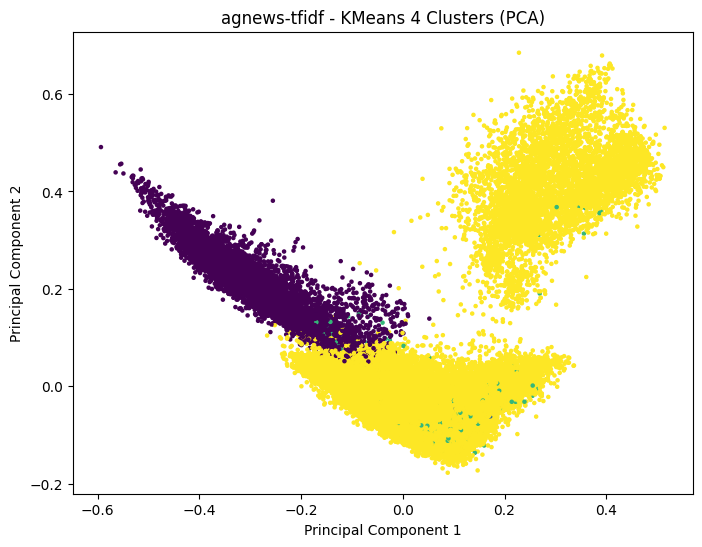

/Users/imranabbas/Documents/MSThesis/deep-doc-clustering/Code/utilities/utils.py:153: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, pd.DataFrame([row])], ignore_index=True)



Running dataset: 20newsgroups with encoder: sbert


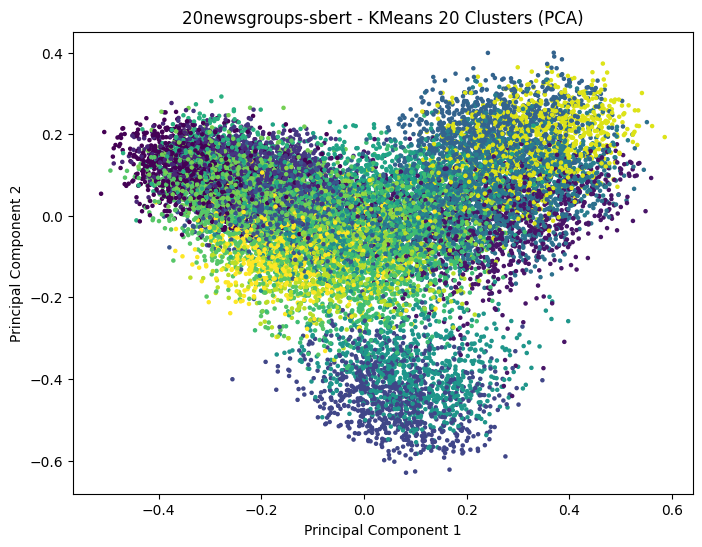


Running dataset: bbcnews with encoder: tfidf


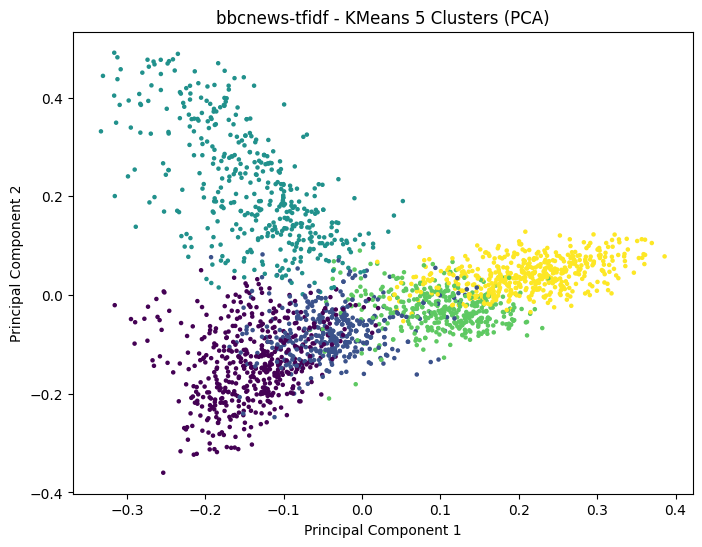


Running dataset: reuters with encoder: tfidf


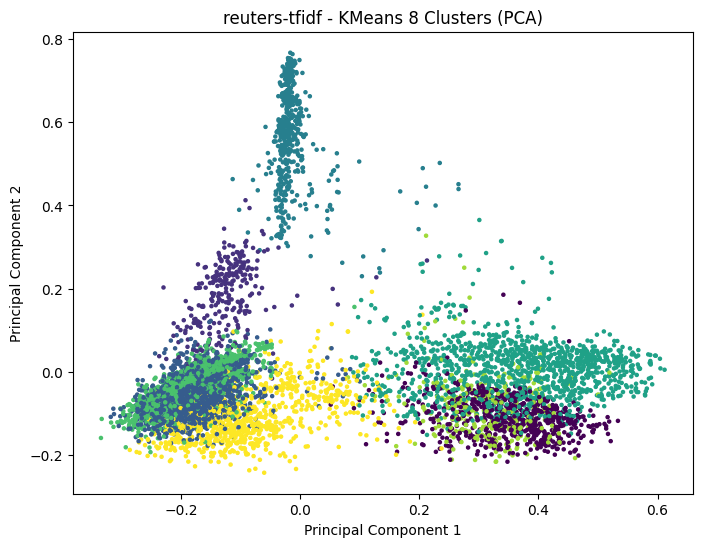


Running dataset: dbpedia with encoder: tfidf


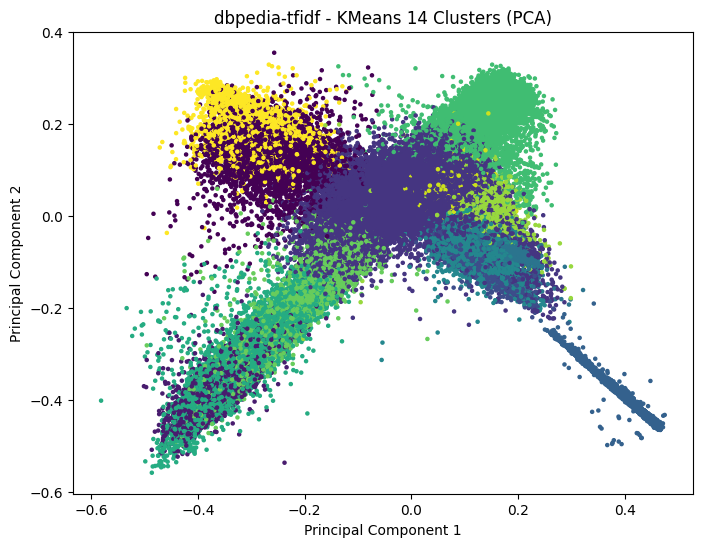


Running dataset: 20newsgroups with encoder: tfidf


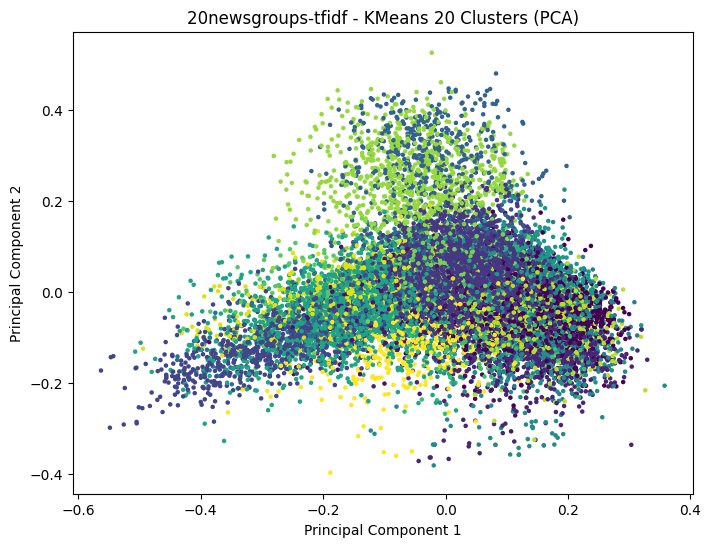


Running dataset: bbcnews with encoder: sbert


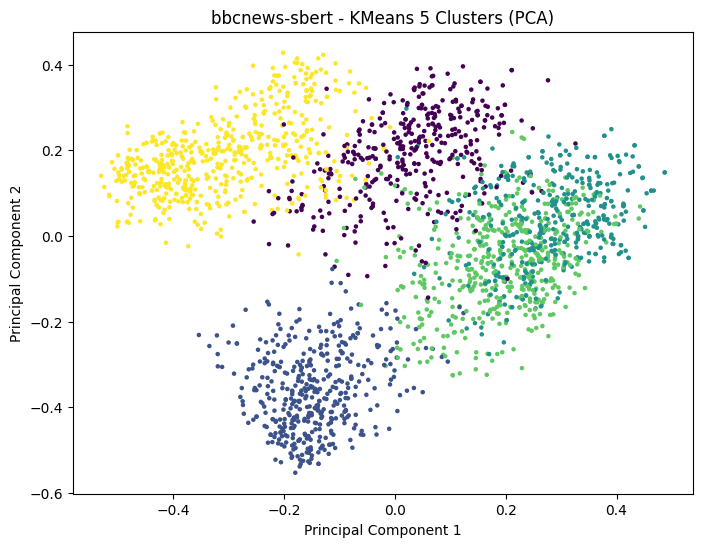


Running dataset: reuters with encoder: sbert


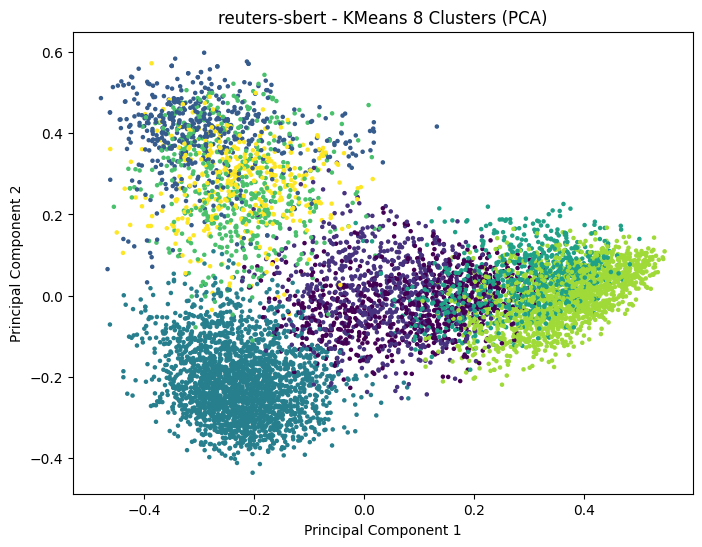


Running dataset: dbpedia with encoder: sbert


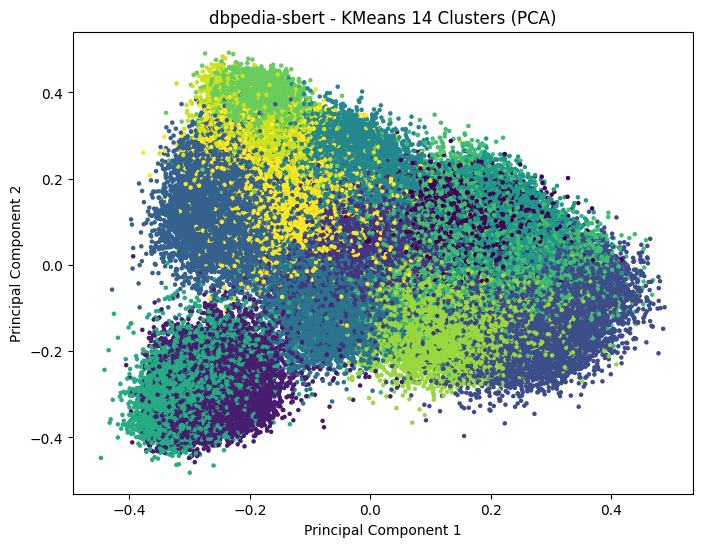


Running dataset: agnews with encoder: sbert


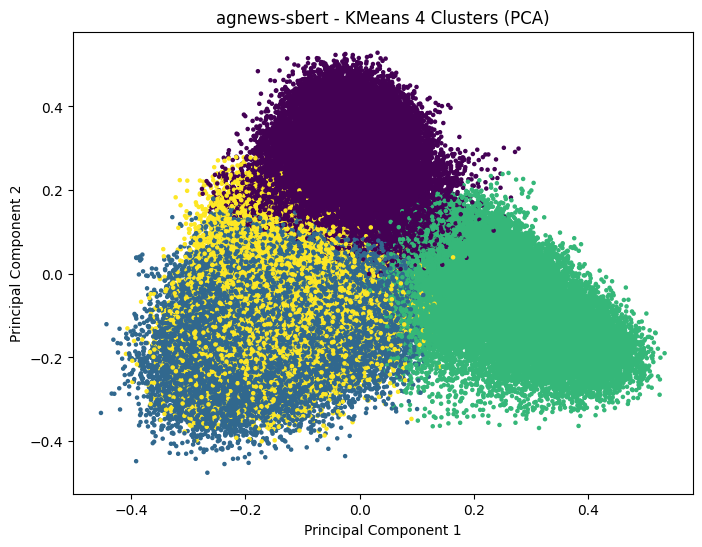

In [ ]:
run_experiments(
        datasets_root="../embeddings",
        csv_path="../outputs/performance_metrics/results.csv"
    )